<a href="https://colab.research.google.com/github/proteinovayas13/My_works/blob/main/Stacking_House_Price_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Решаю задачу регрессии методом Stacking на прмере датасета цен на жилье.

Решаю задачу регрессии методом Stacking и без него на прмере датасета цен на жилье.

In [ ]:
import pandas as pd
import numpy as np

from numpy import mean
from numpy import std
from sklearn.ensemble import StackingRegressor

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score
from numpy import mean, std
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('train.csv')
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.drop(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MiscFeature', 'Alley', 'LotFrontage'], axis=1, inplace=True)
df.drop(['Id'], axis=1)
df.head(5)

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [ ]:
df['Log_SalePrice'] = np.log1p(df['SalePrice'])
df['Log_SalePrice'].skew()

np.float64(0.12134661989685333)

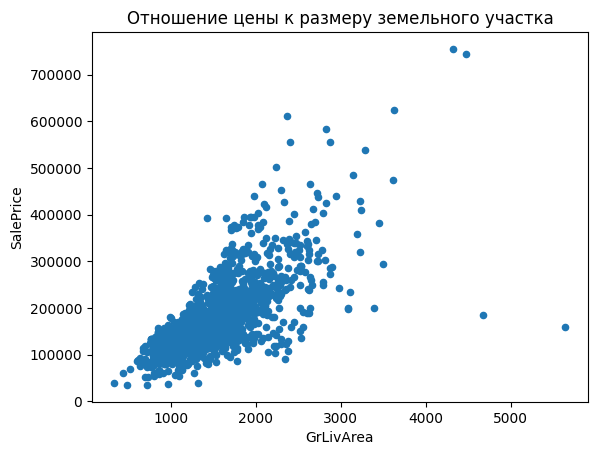

In [ ]:
# Отношение цены к размеру земельного участка
df.plot.scatter(x='GrLivArea', y='SalePrice')
plt.title('Отношение цены к размеру земельного участка')
plt.show()

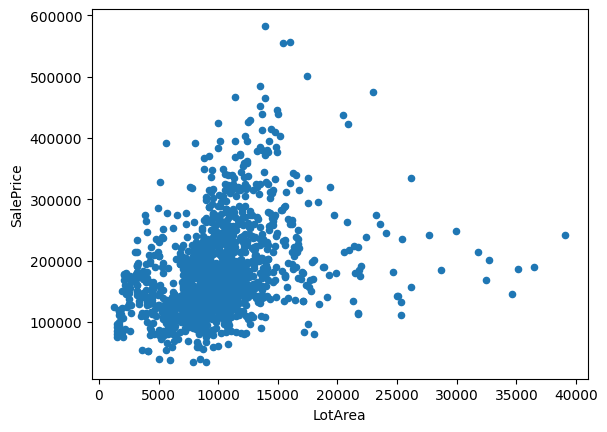

In [ ]:
# Уберем аномальные значения так как их 4, 'эти значения не повлияют на среднюю стоимость на каждый дом
df = df.drop(
    df[
        (df['LotArea'] > 40000) |
        (df['SalePrice'] > 600000)
    ].index
).reset_index(drop=True)

df.plot.scatter(x='LotArea', y='SalePrice')
plt.show()

In [ ]:
numerical_feats = df.dtypes[df.dtypes != 'object'].index
print('Number of Numerical features: ', len(numerical_feats))

categorical_feats = df.dtypes[df.dtypes == 'object'].index
print('Number of Categorical features: ', len(numerical_feats))

Number of Numerical features:  38
Number of Categorical features:  38


In [ ]:
print(df[numerical_feats].columns)
print('*'*100)
print(df[numerical_feats].columns)

Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice', 'Log_SalePrice'],
      dtype='object')
****************************************************************************************************
Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
  

In [ ]:
y = df.SalePrice
df.drop(['SalePrice'], axis=1, inplace=True)

In [ ]:
# Выбираем столбцы только с числовыми значениями
numeric_cols = [cname for cname in df.columns if df[cname].dtype in ['float64', 'int64']]
X = df[numeric_cols].copy()

In [ ]:
# Убедимся, что все NaN заменены на среднее
X = X.fillna(X.mean()) if isinstance(X, (pd.DataFrame, pd.Series)) else np.where(np.isnan(X), np.nanmean(X), X)
y = y.fillna(y.mean()) if isinstance(y, (pd.DataFrame, pd.Series)) else np.where(np.isnan(y), np.nanmean(y), y)

In [ ]:
print('Shape of input data: {} and shape of target variable: {}'. format(X.shape, y.shape))
pd.concat([X, y], axis=1).head()

Shape of input data: (1442, 37) and shape of target variable: (1442,)


,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,Log_SalePrice,SalePrice
0,1,60,8450,7,5,2003,2003,196.0,706,0,...,61,0,0,0,0,0,2,2008,12.247699,208500
1,2,20,9600,6,8,1976,1976,0.0,978,0,...,0,0,0,0,0,0,5,2007,12.109016,181500
2,3,60,11250,7,5,2001,2002,162.0,486,0,...,42,0,0,0,0,0,9,2008,12.317171,223500
3,4,70,9550,7,5,1915,1970,0.0,216,0,...,35,272,0,0,0,0,2,2006,11.849405,140000
4,5,60,14260,8,5,2000,2000,350.0,655,0,...,84,0,0,0,0,0,12,2008,12.429220,250000


In [ ]:
def get_models():
  models = dict()
  models['LinearRegression'] = LinearRegression()
  models['XGBoost'] = XGBRegressor()
  models['KNeighbors'] = KNeighborsRegressor()
  models['LGBMRegressor'] = LGBMRegressor()
  return models

models = get_models()

# Прогнозирование и оценка точности без использования Stacking.


In [ ]:
def evaluate_model(model, X, y):
    cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
    # Используем neg_root_mean_squared_error и затем берем абсолютное значение
    scores = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1, error_score='raise')
    return np.abs(scores)  # Преобразуем отрицательные значения в положительные RMSE

# Используем K-фолд кросс-валидацию для обучения и оценки моделей
results, names = list(), list()
print('Результат (RMSE):')
print()

for name, model in models.items():
    scores = evaluate_model(model, X, y)
    results.append(scores)
    names.append(name)
    print('>%s: %.3f (%.3f)' % (name, np.mean(scores), np.std(scores)))

Результат (RMSE):

>LinearRegression: 18986.552 (3016.870)
>XGBoost: 4576.992 (3161.554)
>KNeighbors: 41017.706 (4464.217)
>LGBMRegressor: 5777.317 (3469.056)


# Прогнозирование с помощью стекинга


In [ ]:
# Результаты базовых моделей
def get_stacking():
  # Базовые модели
  level0 = list()
  level0.append(('LinearRegression', LinearRegression()))
  level0.append(('XGBoost', XGBRegressor()))
  level0.append(('KNeighbors', KNeighborsRegressor()))
  level0.append(('LGBMRegressor', LGBMRegressor()))
  # Мета модель
  level1 = LinearRegression()
  # Определяем ансамбль стекинга
  model = StackingRegressor(estimators=level0, final_estimator=level1, cv=5)
  return model

# Предопределяем модели, заносим еще модель Стекинга
def get_models():
  models = dict()
  models['LinearRegression'] = LinearRegression()
  models['XGBoost'] = XGBRegressor()
  models['KNeighbors'] = KNeighborsRegressor()
  models['LGBMRegressor'] = LGBMRegressor()
  models['Stacking'] = get_stacking()
  return models

# Используем K-фолд кросс-валидацию для обучения и прогноза моделей
def evaluate_model(model, X, y):
  cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
  scores = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1, error_score='raise')
  return abs(scores)

# Определяем базовые модели
models = get_models()
# Используем K-фолд кросс-валидацию для обучения и прогноза моделей
results, names = list(), list()
print("Результаты (RMSE):")
print("------------------")

for name, model in models.items():
    scores = evaluate_model(model, X, y)
    results.append(scores)
    names.append(name)
    print(f"> {name}: Среднее RMSE = {mean(scores):.3f} (±{std(scores):.3f})")

Результаты (RMSE):
------------------
> LinearRegression: Среднее RMSE = 18986.552 (±3016.870)
> XGBoost: Среднее RMSE = 4576.992 (±3161.554)
> KNeighbors: Среднее RMSE = 41017.706 (±4464.217)
> LGBMRegressor: Среднее RMSE = 5777.317 (±3469.056)
> Stacking: Среднее RMSE = 4455.829 (±3226.768)


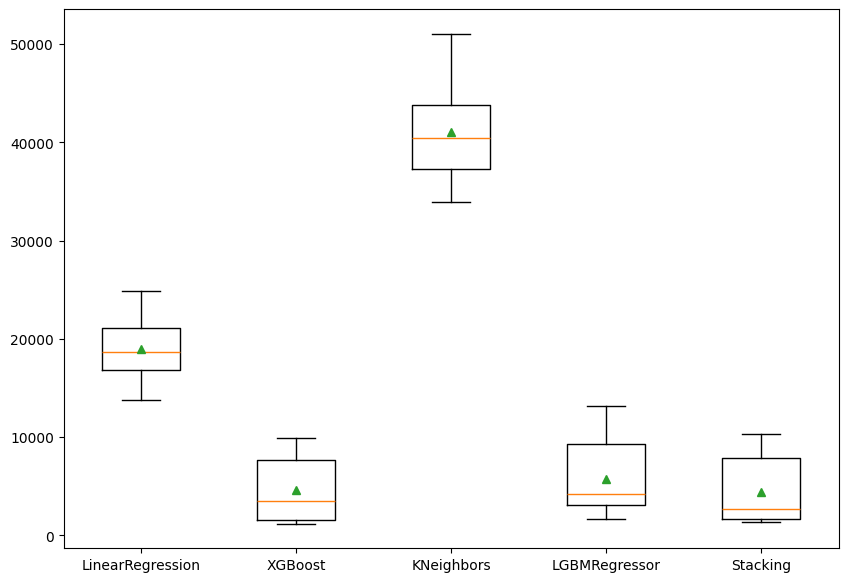

In [ ]:
plt.figure(figsize=(10, 7))

plt.boxplot(results, labels=names, showmeans=True)
plt.show()

Вывод

Целевая переменная SalePrice лучше всего коррелирует с площадью участка ( LotArea )
Лучшую метрику показывает модель Stacking методом XGBoost: 4576.992 (3161.554)

Результат модели Stacking оказались лучше чем у модели Blending
Stacking: Среднее RMSE = 4455.829 (±3226.768)

Результат модели Blending Лучшую метрику показывает  Blending - R2: 0.459 - MAE: 40320.330